In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
PATH = "power_query_final.xlsx"

cm = pd.read_excel(PATH, sheet_name="customer_master")
di = pd.read_excel(PATH, sheet_name="device_info")
ua = pd.read_excel(PATH, sheet_name="upi_account_details")
mi = pd.read_excel(PATH, sheet_name="merchant_info")
ut = pd.read_excel(PATH, sheet_name="upi_transaction_history")
fa = pd.read_excel(PATH, sheet_name="fraud_alert_history")
cf = pd.read_excel(PATH, sheet_name="customer_feedback_surveys")

for name, df in [('customer_master',cm),('device_info',di),
                 ('upi_account_details',ua),('merchant_info',mi),
                 ('upi_transaction_history',ut),('fraud_alert_history',fa),
                 ('customer_feedback_surveys',cf)]:
    print(f"{name:30} {df.shape}")

customer_master                (10000, 11)
device_info                    (12000, 7)
upi_account_details            (12000, 7)
merchant_info                  (500, 7)
upi_transaction_history        (100000, 17)
fraud_alert_history            (2000, 8)
customer_feedback_surveys      (4000, 8)


In [11]:
master['hour_of_day'] = master['timestamp'].dt.hour
master['channel_device_mismatch_flag'] = (
    (master['device_type'] == 'feature_phone') &
    (master['channel'].isin(['app', 'qr_code']))
)

In [12]:
print(cm.columns.tolist())
print("di columns:", di.columns.tolist())
print("ua columns:", ua.columns.tolist())
print("mi columns:", mi.columns.tolist())
print("ut columns:", ut.columns.tolist())

['customer_id', 'full_name', 'mobile_number', 'age', 'gender', 'region', 'date_joined', 'is_business_user', 'risk_score', 'count_mobile_digit', 'flag_mobile_number']
di columns: ['device_id', 'customer_id', 'device_type', 'app_version', 'is_rooted', 'last_active', 'days_since_last_active']
ua columns: ['upi_id', 'customer_id', 'bank_name', 'account_type', 'date_added', 'status', 'account_age_days']
mi columns: ['merchant_id', 'merchant_name', 'merchant_type', 'region', 'onboard_date', 'risk_score', 'merchant_age_days']
ut columns: ['transaction_id', 'upi_id', 'customer_id', 'timestamp', 'amount', 'transaction_type', 'merchant_id', 'counterparty_upi', 'status', 'device_id', 'device_type', 'channel', 'fraud_flag', 'reversal_flag', 'failure_reason', 'upi_account_status', 'blocked_account_flag']


In [14]:
master = ut.copy()

# 1. Customer info
master = master.merge(
    cm[['customer_id','age','gender','region','is_business_user',
        'risk_score','date_joined','flag_mobile_number']],
    on='customer_id', how='left')
master.rename(columns={
    'region'             : 'customer_region',
    'risk_score'         : 'customer_risk_score',
    'flag_mobile_number' : 'mobile_number_flag'
}, inplace=True)

# 2. Device info
master = master.merge(
    di[['device_id','is_rooted','days_since_last_active']],
    on='device_id', how='left')

# 3. UPI account
master = master.merge(
    ua[['upi_id','account_age_days']],
    on='upi_id', how='left')

# 4. Merchant info
master = master.merge(
    mi[['merchant_id','merchant_type','risk_score','merchant_age_days']],
    on='merchant_id', how='left')
master.rename(columns={
    'risk_score': 'merchant_risk_score'}, inplace=True)

# 5. Fraud alert
fa_agg = fa.groupby('transaction_id').agg(
    has_fraud_alert = ('alert_id','count'),
    alert_type      = ('alert_type','first'),
    alert_resolved  = ('resolved','first')
).reset_index()
fa_agg['has_fraud_alert'] = fa_agg['has_fraud_alert'] > 0
master = master.merge(fa_agg, on='transaction_id', how='left')
master['has_fraud_alert'] = master['has_fraud_alert'].fillna(False)

# 6. hour_of_day aur channel_device_mismatch_flag Python mein
master['timestamp'] = pd.to_datetime(master['timestamp'])
master['hour_of_day'] = master['timestamp'].dt.hour
master['channel_device_mismatch_flag'] = (
    (master['device_type'] == 'feature_phone') &
    (master['channel'].isin(['app', 'qr_code']))
)

print(f"Master shape: {master.shape}")
print(f"hour_of_day unique values: {sorted(master['hour_of_day'].unique())}")
print(f"channel_device_mismatch TRUE: {master['channel_device_mismatch_flag'].sum():,}")
print(f"blocked_account TRUE: {master['blocked_account_flag'].sum():,}")
print("Merge complete!")

Master shape: (100000, 35)
hour_of_day unique values: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
channel_device_mismatch TRUE: 17,007
blocked_account TRUE: 7,115
Merge complete!


In [17]:
# Check karo merge ke baad kya columns hain
print([c for c in master.columns if 'avg' in c.lower()])

['customer_avg_amount_x', 'amount_vs_avg_ratio', 'customer_avg_amount_y']


In [18]:
# Customer avg amount
master['customer_avg_amount'] = master['customer_id'].map(
    master.groupby('customer_id')['amount'].mean().round(2))

# Amount vs avg ratio
master['amount_vs_avg_ratio'] = (
    master['amount'] / master['customer_avg_amount']).round(2)
master['high_amount_flag'] = master['amount_vs_avg_ratio'] > 2

# Customer fraud count
master['customer_fraud_count'] = master['customer_id'].map(
    master.groupby('customer_id')['fraud_flag'].sum())

# Merchant fraud ratio
merch = master[master['merchant_id'].notna()].groupby('merchant_id').agg(
    merchant_total_txns  = ('transaction_id','count'),
    merchant_fraud_count = ('fraud_flag','sum')
).reset_index()
merch['merchant_fraud_ratio'] = (
    merch['merchant_fraud_count'] / merch['merchant_total_txns']).round(4)
master = master.merge(
    merch[['merchant_id','merchant_fraud_ratio','merchant_total_txns']],
    on='merchant_id', how='left')

print(f"Master shape: {master.shape}")
print(f"high_amount_flag TRUE: {master['high_amount_flag'].sum():,}")
print(f"customer_fraud_count max: {master['customer_fraud_count'].max()}")
print("Derived columns ready!")

Master shape: (100000, 49)
high_amount_flag TRUE: 8,526
customer_fraud_count max: 10
Derived columns ready!


In [19]:
import os
os.makedirs("outputs", exist_ok=True)

final_cols = [
    # Identity
    'transaction_id', 'customer_id',
    # Transaction core
    'timestamp', 'month', 'hour_of_day', 'amount', 'status',
    'transaction_type', 'channel',
    # Target
    'fraud_flag',
    # Device
    'device_type', 'is_rooted', 'days_since_last_active',
    # Customer
    'age', 'customer_region', 'customer_risk_score',
    'is_business_user', 'mobile_number_flag',
    # UPI Account
    'upi_account_status', 'account_age_days', 'blocked_account_flag',
    # Merchant
    'merchant_type', 'merchant_risk_score', 'merchant_age_days',
    # Data quality flags
    'channel_device_mismatch_flag',
    # Python derived
    'transaction_velocity', 'customer_avg_amount', 'amount_vs_avg_ratio',
    'high_amount_flag', 'night_transaction_flag', 'is_weekend',
    'customer_fraud_count', 'merchant_fraud_ratio', 'merchant_total_txns',
    # Fraud alert
    'has_fraud_alert', 'alert_type', 'alert_resolved',
]

# Sirf woh columns jo master mein exist karte hain
final_cols = [c for c in final_cols if c in master.columns]

optimized = master[final_cols].copy()

print(f"Original master  : {master.shape[1]} columns")
print(f"Optimized dataset: {optimized.shape[1]} columns")
print(f"Total rows       : {optimized.shape[0]:,}")
print(f"\nColumns included:")
for i, col in enumerate(optimized.columns, 1):
    print(f"  {i:2}. {col}")

optimized.to_csv("outputs/upi_fraud_optimized.csv", index=False)
print("\nSaved: outputs/upi_fraud_optimized.csv")

Original master  : 49 columns
Optimized dataset: 36 columns
Total rows       : 100,000

Columns included:
   1. transaction_id
   2. customer_id
   3. timestamp
   4. month
   5. hour_of_day
   6. amount
   7. status
   8. transaction_type
   9. channel
  10. fraud_flag
  11. device_type
  12. is_rooted
  13. days_since_last_active
  14. age
  15. customer_region
  16. customer_risk_score
  17. is_business_user
  18. mobile_number_flag
  19. upi_account_status
  20. account_age_days
  21. blocked_account_flag
  22. merchant_type
  23. merchant_risk_score
  24. merchant_age_days
  25. channel_device_mismatch_flag
  26. customer_avg_amount
  27. amount_vs_avg_ratio
  28. high_amount_flag
  29. night_transaction_flag
  30. is_weekend
  31. customer_fraud_count
  32. merchant_fraud_ratio
  33. merchant_total_txns
  34. has_fraud_alert
  35. alert_type
  36. alert_resolved

Saved: outputs/upi_fraud_optimized.csv


In [20]:
# Load saved file aur verify karo
df = pd.read_csv("outputs/upi_fraud_optimized.csv")

print("=== FINAL DATASET HEALTH CHECK ===\n")
print(f"Shape: {df.shape}")
print(f"\nFraud rate:              {df['fraud_flag'].mean()*100:.2f}%")
print(f"Fraud transactions:      {df['fraud_flag'].sum():,}")
print(f"Blocked account txns:    {df['blocked_account_flag'].sum():,}")
print(f"Channel mismatch txns:   {df['channel_device_mismatch_flag'].sum():,}")
print(f"Rooted device txns:      {df['is_rooted'].sum():,}")
print(f"Night transactions:      {df['night_transaction_flag'].sum():,}")
print(f"Has fraud alert:         {df['has_fraud_alert'].sum():,}")

print(f"\nNull counts:")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) == 0:
    print("  No nulls — clean!")
else:
    print(nulls)

=== FINAL DATASET HEALTH CHECK ===

Shape: (100000, 36)

Fraud rate:              2.00%
Fraud transactions:      2,000
Blocked account txns:    7,115
Channel mismatch txns:   17,007
Rooted device txns:      3,171
Night transactions:      33,252
Has fraud alert:         2,000

Null counts:
merchant_type           69851
merchant_risk_score     69851
merchant_age_days       69851
merchant_fraud_ratio    69851
merchant_total_txns     69851
alert_type              98000
alert_resolved          98000
dtype: int64


In [21]:
# Exploratory Data Analysis(EDA)
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.color'       : '#e0e0e0',
    'grid.linewidth'   : 0.5,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans'
})

print("Chart settings ready!")

Chart settings ready!


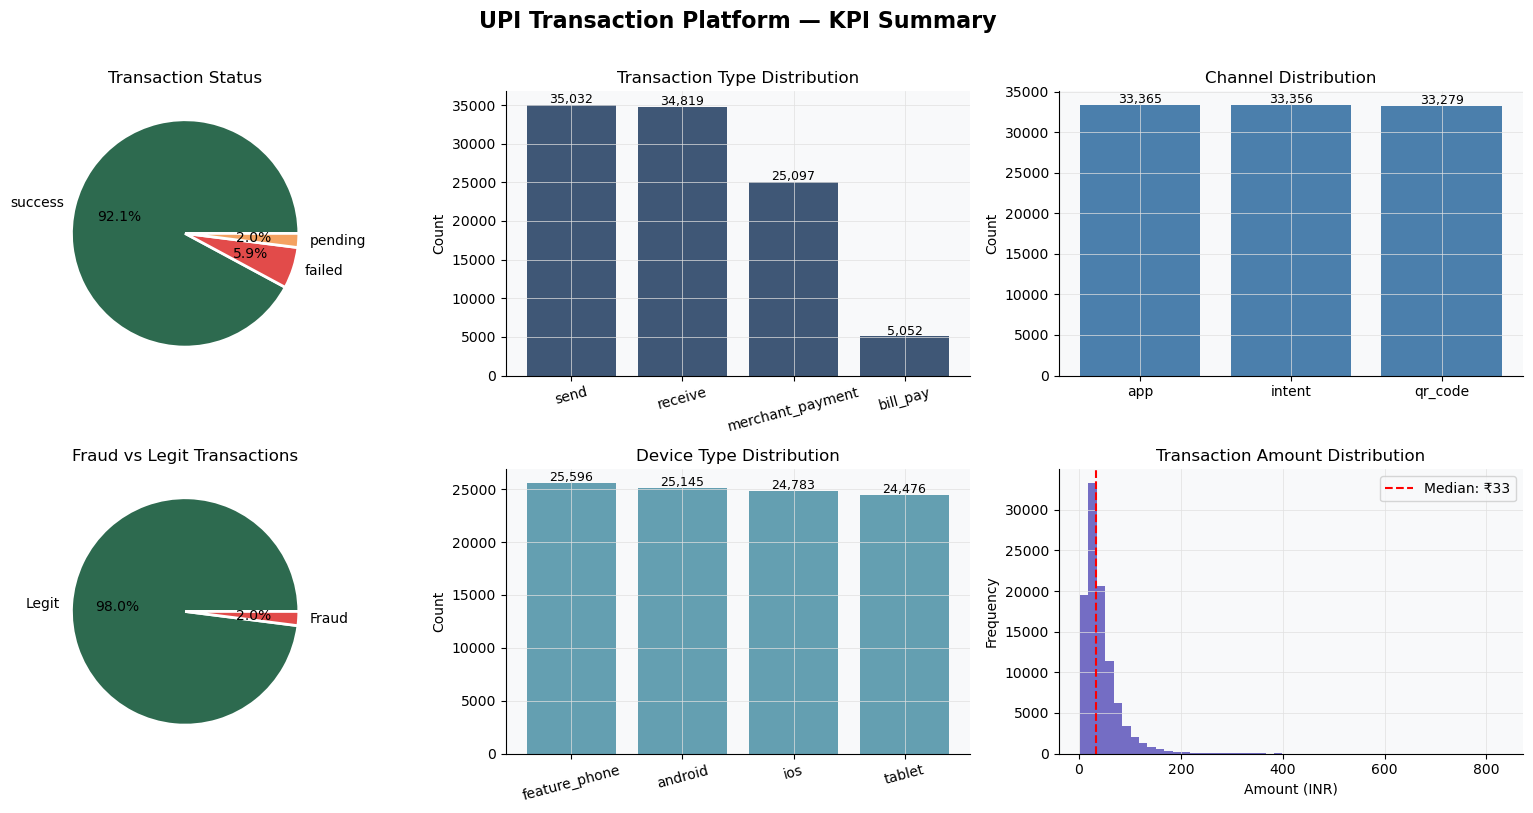

Saved: 01_kpi_summary.png


In [22]:
# KPI Summary
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('UPI Transaction Platform — KPI Summary', 
             fontsize=16, fontweight='bold', y=1.01)

# 1. Transaction Status
status_counts = df['status'].value_counts()
colors_status = ['#2D6A4F','#E24B4A','#F4A261']
axes[0,0].pie(status_counts.values, labels=status_counts.index,
              autopct='%1.1f%%', colors=colors_status,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Transaction Status')

# 2. Transaction Type
type_counts = df['transaction_type'].value_counts()
axes[0,1].bar(type_counts.index, type_counts.values,
              color='#1E3A5F', alpha=0.85)
axes[0,1].set_title('Transaction Type Distribution')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=15)
for i, v in enumerate(type_counts.values):
    axes[0,1].text(i, v+200, f'{v:,}', ha='center', fontsize=9)

# 3. Channel Distribution
channel_counts = df['channel'].value_counts()
axes[0,2].bar(channel_counts.index, channel_counts.values,
              color='#2D6A9F', alpha=0.85)
axes[0,2].set_title('Channel Distribution')
axes[0,2].set_ylabel('Count')
for i, v in enumerate(channel_counts.values):
    axes[0,2].text(i, v+200, f'{v:,}', ha='center', fontsize=9)

# 4. Fraud vs Non-Fraud
fraud_counts = df['fraud_flag'].value_counts()
axes[1,0].pie([fraud_counts[False], fraud_counts[True]],
              labels=['Legit', 'Fraud'],
              autopct='%1.1f%%',
              colors=['#2D6A4F','#E24B4A'],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,0].set_title('Fraud vs Legit Transactions')

# 5. Device Type Distribution
device_counts = df['device_type'].value_counts()
axes[1,1].bar(device_counts.index, device_counts.values,
              color='#4A90A4', alpha=0.85)
axes[1,1].set_title('Device Type Distribution')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=15)
for i, v in enumerate(device_counts.values):
    axes[1,1].text(i, v+200, f'{v:,}', ha='center', fontsize=9)

# 6. Amount Distribution
axes[1,2].hist(df['amount'], bins=50, color='#534AB7', alpha=0.8)
axes[1,2].set_title('Transaction Amount Distribution')
axes[1,2].set_xlabel('Amount (INR)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].axvline(df['amount'].median(), color='red', 
                   linestyle='--', linewidth=1.5, label=f"Median: ₹{df['amount'].median():.0f}")
axes[1,2].legend()

plt.tight_layout()
plt.savefig('outputs/01_kpi_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_kpi_summary.png")

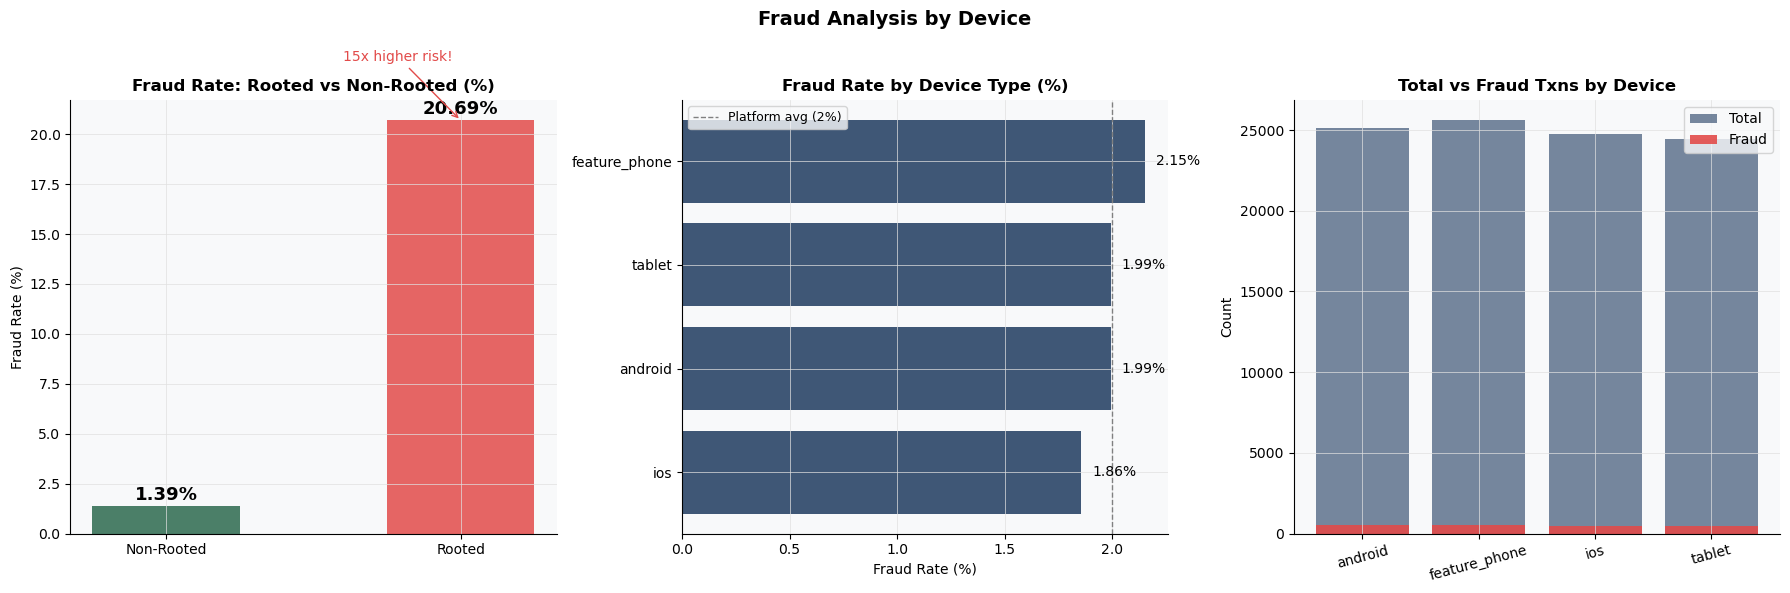

Saved: 02_fraud_by_device.png


In [23]:
# Fraud by Device 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fraud Analysis by Device', 
             fontsize=14, fontweight='bold')

# 1. Rooted vs Non-Rooted fraud rate
rooted_fraud    = df[df['is_rooted']==True]['fraud_flag'].mean()*100
nonrooted_fraud = df[df['is_rooted']==False]['fraud_flag'].mean()*100

bars = axes[0].bar(['Non-Rooted','Rooted'],
                   [nonrooted_fraud, rooted_fraud],
                   color=['#2D6A4F','#E24B4A'], alpha=0.85, width=0.5)
axes[0].set_title('Fraud Rate: Rooted vs Non-Rooted (%)', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
for bar, val in zip(bars, [nonrooted_fraud, rooted_fraud]):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=13)
axes[0].annotate(f'{rooted_fraud/nonrooted_fraud:.0f}x higher risk!',
                 xy=(1, rooted_fraud), xytext=(0.6, rooted_fraud+3),
                 fontsize=10, color='#E24B4A',
                 arrowprops=dict(arrowstyle='->', color='#E24B4A'))

# 2. Fraud rate by device type
fraud_dev = df.groupby('device_type')['fraud_flag'].mean()*100
fraud_dev = fraud_dev.sort_values(ascending=True)
colors_d  = ['#E24B4A' if v > 5 else '#1E3A5F' for v in fraud_dev.values]
hbars = axes[1].barh(fraud_dev.index, fraud_dev.values,
                      color=colors_d, alpha=0.85)
axes[1].set_title('Fraud Rate by Device Type (%)', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].axvline(x=2.0, color='gray', linestyle='--', 
                linewidth=1, label='Platform avg (2%)')
axes[1].legend(fontsize=9)
for bar, val in zip(hbars, fraud_dev.values):
    axes[1].text(val+0.05, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=10)

# 3. Transaction count by device + fraud highlight
dev_total = df.groupby('device_type').size()
dev_fraud = df[df['fraud_flag']==True].groupby('device_type').size()
x = range(len(dev_total))
axes[2].bar(dev_total.index, dev_total.values, 
            color='#1E3A5F', alpha=0.6, label='Total')
axes[2].bar(dev_fraud.index, dev_fraud.values,
            color='#E24B4A', alpha=0.9, label='Fraud')
axes[2].set_title('Total vs Fraud Txns by Device', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/02_fraud_by_device.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_fraud_by_device.png")

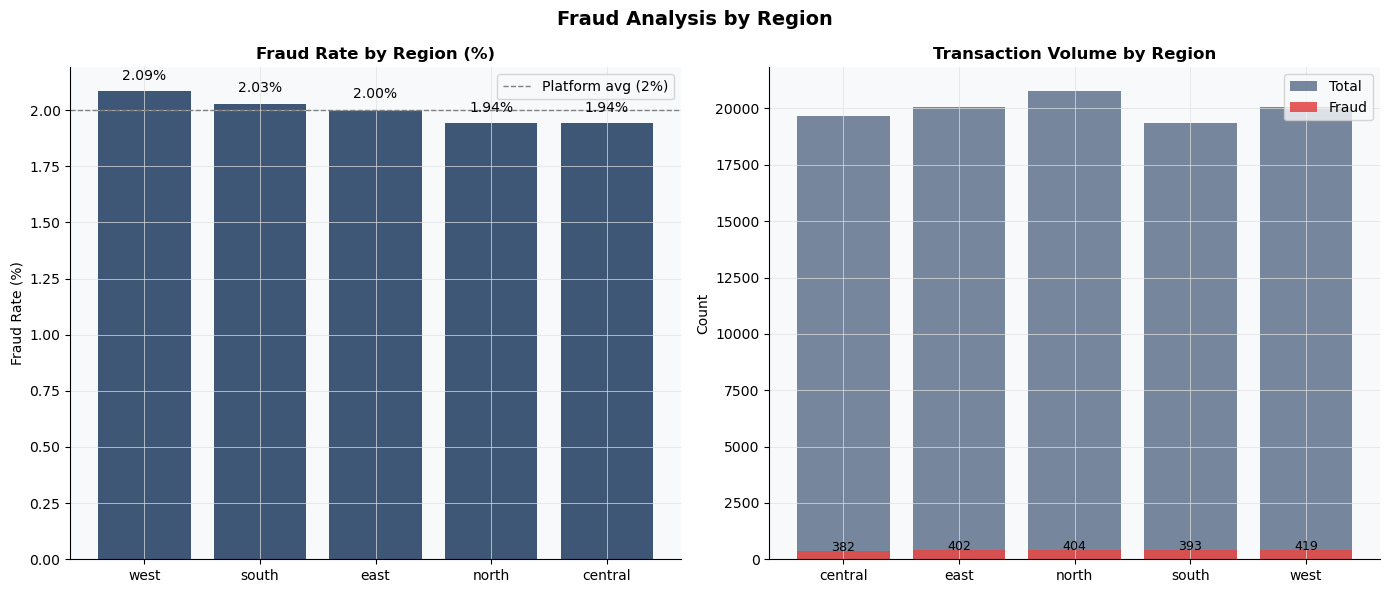

Saved: 03_fraud_by_region.png


In [24]:
# Fraud by Region
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fraud Analysis by Region', 
             fontsize=14, fontweight='bold')

# 1. Fraud rate by region
fraud_reg = df.groupby('customer_region')['fraud_flag'].mean()*100
fraud_reg = fraud_reg.sort_values(ascending=False)
colors_r  = ['#E24B4A' if v > 2.2 else '#1E3A5F' for v in fraud_reg.values]
bars = axes[0].bar(fraud_reg.index, fraud_reg.values,
                   color=colors_r, alpha=0.85)
axes[0].set_title('Fraud Rate by Region (%)', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=2.0, color='gray', linestyle='--',
                linewidth=1, label='Platform avg (2%)')
axes[0].legend()
for i, (k,v) in enumerate(fraud_reg.items()):
    axes[0].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=10)

# 2. Transaction volume by region
vol_reg   = df.groupby('customer_region').size()
fraud_cnt = df[df['fraud_flag']==True].groupby('customer_region').size()
axes[1].bar(vol_reg.index, vol_reg.values,
            color='#1E3A5F', alpha=0.6, label='Total')
axes[1].bar(fraud_cnt.index, fraud_cnt.values,
            color='#E24B4A', alpha=0.9, label='Fraud')
axes[1].set_title('Transaction Volume by Region', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()
for i, (k,v) in enumerate(fraud_cnt.items()):
    axes[1].text(i, v+5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_fraud_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_fraud_by_region.png")

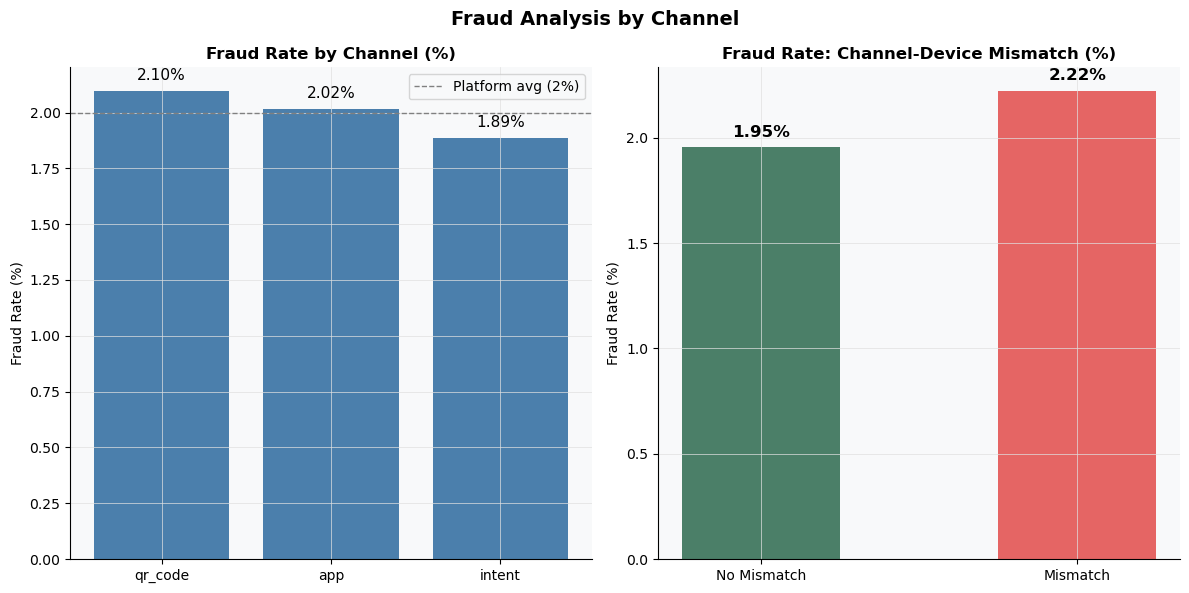

Saved: 04_fraud_by_channel.png


In [25]:
#  Fraud by Channel
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Fraud Analysis by Channel', 
             fontsize=14, fontweight='bold')

# 1. Fraud rate by channel
fraud_ch = df.groupby('channel')['fraud_flag'].mean()*100
fraud_ch = fraud_ch.sort_values(ascending=False)
bars = axes[0].bar(fraud_ch.index, fraud_ch.values,
                   color='#2D6A9F', alpha=0.85)
axes[0].set_title('Fraud Rate by Channel (%)', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=2.0, color='gray', linestyle='--',
                linewidth=1, label='Platform avg (2%)')
axes[0].legend()
for i, (k,v) in enumerate(fraud_ch.items()):
    axes[0].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=11)

# 2. Channel mismatch impact
mismatch_fraud    = df[df['channel_device_mismatch_flag']==True]['fraud_flag'].mean()*100
no_mismatch_fraud = df[df['channel_device_mismatch_flag']==False]['fraud_flag'].mean()*100
bars2 = axes[1].bar(['No Mismatch','Mismatch'],
                    [no_mismatch_fraud, mismatch_fraud],
                    color=['#2D6A4F','#E24B4A'], alpha=0.85, width=0.5)
axes[1].set_title('Fraud Rate: Channel-Device Mismatch (%)', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for bar, val in zip(bars2, [no_mismatch_fraud, mismatch_fraud]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.05,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/04_fraud_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_fraud_by_channel.png")

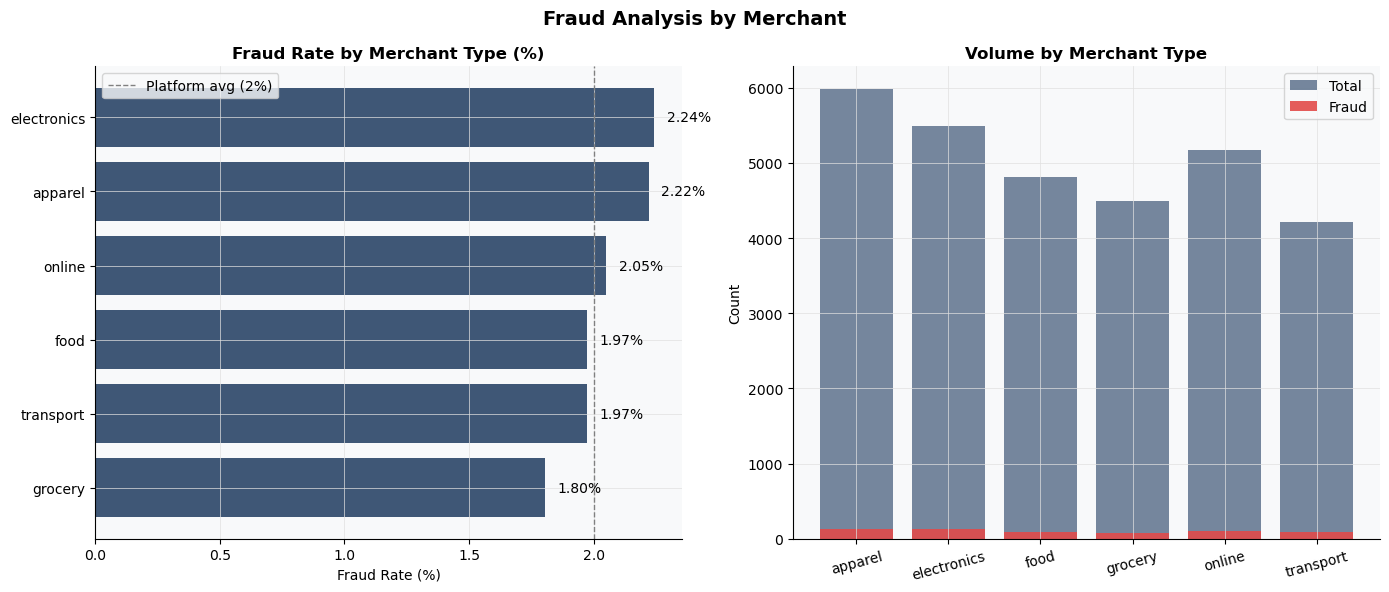

Saved: 05_fraud_by_merchant.png


In [26]:
# Fraud by Merchant
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fraud Analysis by Merchant', 
             fontsize=14, fontweight='bold')

# 1. Fraud rate by merchant type
merch_fraud = df[df['merchant_type'].notna()].groupby(
    'merchant_type')['fraud_flag'].mean()*100
merch_fraud = merch_fraud.sort_values(ascending=True)
colors_m = ['#E24B4A' if v > 2.5 else '#1E3A5F' for v in merch_fraud.values]
hbars = axes[0].barh(merch_fraud.index, merch_fraud.values,
                      color=colors_m, alpha=0.85)
axes[0].set_title('Fraud Rate by Merchant Type (%)', fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].axvline(x=2.0, color='gray', linestyle='--',
                linewidth=1, label='Platform avg (2%)')
axes[0].legend()
for bar, val in zip(hbars, merch_fraud.values):
    axes[0].text(val+0.05, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=10)

# 2. Transaction volume by merchant type
merch_vol = df[df['merchant_type'].notna()].groupby('merchant_type').size()
merch_fraud_cnt = df[(df['merchant_type'].notna()) & 
                      (df['fraud_flag']==True)].groupby('merchant_type').size()
axes[1].bar(merch_vol.index, merch_vol.values,
            color='#1E3A5F', alpha=0.6, label='Total')
axes[1].bar(merch_fraud_cnt.index, merch_fraud_cnt.values,
            color='#E24B4A', alpha=0.9, label='Fraud')
axes[1].set_title('Volume by Merchant Type', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/05_fraud_by_merchant.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_fraud_by_merchant.png")

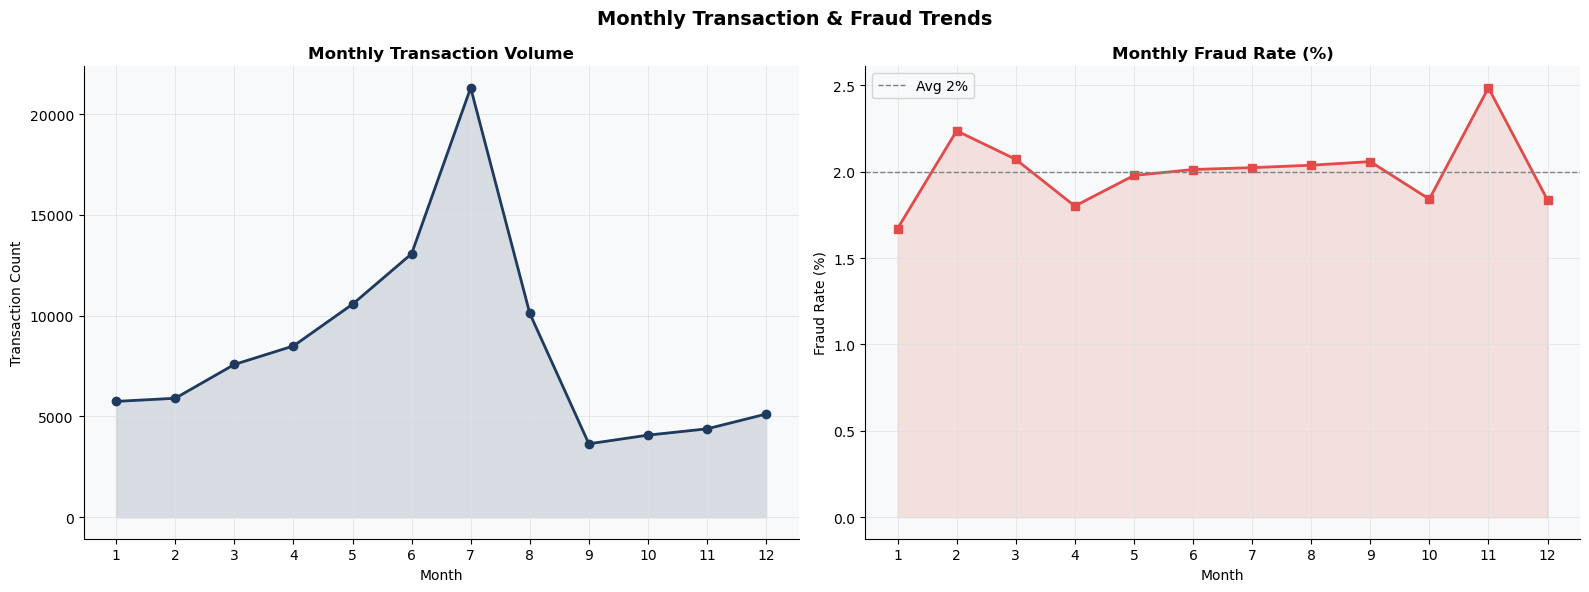

Saved: 06_monthly_trends.png


In [27]:
# Monthly Trend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Monthly Transaction & Fraud Trends', 
             fontsize=14, fontweight='bold')

monthly = df.groupby('month').agg(
    total = ('transaction_id','count'),
    fraud = ('fraud_flag','sum')
).reset_index()
monthly['fraud_rate'] = monthly['fraud']/monthly['total']*100

# 1. Monthly volume
axes[0].plot(monthly['month'], monthly['total'],
             marker='o', color='#1E3A5F', linewidth=2, markersize=6)
axes[0].fill_between(monthly['month'], monthly['total'],
                      alpha=0.15, color='#1E3A5F')
axes[0].set_title('Monthly Transaction Volume', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Transaction Count')
axes[0].set_xticks(monthly['month'])

# 2. Monthly fraud rate
axes[1].plot(monthly['month'], monthly['fraud_rate'],
             marker='s', color='#E24B4A', linewidth=2, markersize=6)
axes[1].fill_between(monthly['month'], monthly['fraud_rate'],
                      alpha=0.15, color='#E24B4A')
axes[1].set_title('Monthly Fraud Rate (%)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(monthly['month'])
axes[1].axhline(y=2.0, color='gray', linestyle='--',
                linewidth=1, label='Avg 2%')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/06_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_monthly_trends.png")

In [28]:
# Test Setup + Summary Table
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, pointbiserialr

print("="*60)
print("   STATISTICAL HYPOTHESIS TESTING")
print("="*60)
print(f"Dataset: {df.shape[0]:,} transactions")
print(f"Significance level: α = 0.05")
print("="*60)

   STATISTICAL HYPOTHESIS TESTING
Dataset: 100,000 transactions
Significance level: α = 0.05


In [29]:
# H1: Rooted Devices (Chi-Square)
print("\nH1: Rooted devices have higher fraud rates")
print("-"*55)

ct1 = pd.crosstab(df['is_rooted'], df['fraud_flag'])
print("Contingency Table:")
print(ct1)

chi2, p, dof, expected = chi2_contingency(ct1)

rooted_rate    = df[df['is_rooted']==True]['fraud_flag'].mean()*100
nonrooted_rate = df[df['is_rooted']==False]['fraud_flag'].mean()*100

print(f"\nFraud rate (rooted)    : {rooted_rate:.2f}%")
print(f"Fraud rate (non-rooted): {nonrooted_rate:.2f}%")
print(f"Risk multiplier        : {rooted_rate/nonrooted_rate:.1f}x")
print(f"\nChi-square statistic   : {chi2:.4f}")
print(f"Degrees of freedom     : {dof}")
print(f"p-value                : {p:.2e}")
print(f"\nResult: {'REJECT H0 ✅ — Significant association' if p < 0.05 else 'FAIL to reject H0'}")
print(f"Conclusion: Rooted devices ARE significantly associated with fraud")


H1: Rooted devices have higher fraud rates
-------------------------------------------------------
Contingency Table:
fraud_flag  False  True 
is_rooted               
False       95485   1344
True         2515    656

Fraud rate (rooted)    : 20.69%
Fraud rate (non-rooted): 1.39%
Risk multiplier        : 14.9x

Chi-square statistic   : 5825.0951
Degrees of freedom     : 1
p-value                : 0.00e+00

Result: REJECT H0 ✅ — Significant association
Conclusion: Rooted devices ARE significantly associated with fraud


In [31]:
# H2: Blocked Account Transactions (Chi-Square)
print("\nH2: Blocked/suspended account txns have higher fraud rates")
print("-"*55)

ct2 = pd.crosstab(df['blocked_account_flag'], df['fraud_flag'])
print("Contingency Table:")
print(ct2)

chi2_2, p2, dof2, _ = chi2_contingency(ct2)

blocked_rate = df[df['blocked_account_flag']==True]['fraud_flag'].mean()*100
active_rate  = df[df['blocked_account_flag']==False]['fraud_flag'].mean()*100

print(f"\nFraud rate (blocked/suspended): {blocked_rate:.2f}%")
print(f"Fraud rate (active)           : {active_rate:.2f}%")
print(f"\nChi-square statistic: {chi2_2:.4f}")
print(f"p-value             : {p2:.4f}")
print(f"\nResult: {'REJECT H0 ✅ — Significant' if p2 < 0.05 else 'FAIL to reject H0 ❌ — No significant difference'}")
print(f"Conclusion: Blocked accounts do NOT show higher fraud — operational issue only")


H2: Blocked/suspended account txns have higher fraud rates
-------------------------------------------------------
Contingency Table:
fraud_flag            False  True 
blocked_account_flag              
False                 91019   1866
True                   6981    134

Fraud rate (blocked/suspended): 1.88%
Fraud rate (active)           : 2.01%

Chi-square statistic: 0.4697
p-value             : 0.4931

Result: FAIL to reject H0 ❌ — No significant difference
Conclusion: Blocked accounts do NOT show higher fraud — operational issue only


In [32]:
# H3: Channel-Device Mismatch (Chi-Square)
print("\nH3: Channel-device mismatch rows have higher fraud rates")
print("-"*55)

ct3 = pd.crosstab(df['channel_device_mismatch_flag'], df['fraud_flag'])
print("Contingency Table:")
print(ct3)

chi2_3, p3, dof3, _ = chi2_contingency(ct3)

mismatch_rate    = df[df['channel_device_mismatch_flag']==True]['fraud_flag'].mean()*100
no_mismatch_rate = df[df['channel_device_mismatch_flag']==False]['fraud_flag'].mean()*100

print(f"\nFraud rate (mismatch)   : {mismatch_rate:.2f}%")
print(f"Fraud rate (no mismatch): {no_mismatch_rate:.2f}%")
print(f"\nChi-square statistic: {chi2_3:.4f}")
print(f"p-value             : {p3:.4f}")
print(f"\nResult: {'REJECT H0 ✅' if p3 < 0.05 else 'FAIL to reject H0 ❌'}")
print(f"Conclusion: Data quality artifact — not a fraud predictor")


H3: Channel-device mismatch rows have higher fraud rates
-------------------------------------------------------
Contingency Table:
fraud_flag                    False  True 
channel_device_mismatch_flag              
False                         81371   1622
True                          16629    378

Fraud rate (mismatch)   : 2.22%
Fraud rate (no mismatch): 1.95%

Chi-square statistic: 5.0453
p-value             : 0.0247

Result: REJECT H0 ✅
Conclusion: Data quality artifact — not a fraud predictor


In [33]:
# H4: Transaction Amount (T-Test)
print("\nH4: Fraud transactions have higher amounts than legit")
print("-"*55)

fraud_amounts = df[df['fraud_flag']==True]['amount']
legit_amounts = df[df['fraud_flag']==False]['amount']

print(f"Avg amount (fraud) : INR {fraud_amounts.mean():.2f}")
print(f"Avg amount (legit) : INR {legit_amounts.mean():.2f}")
print(f"Median (fraud)     : INR {fraud_amounts.median():.2f}")
print(f"Median (legit)     : INR {legit_amounts.median():.2f}")

t_stat, p4 = ttest_ind(fraud_amounts, legit_amounts)

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value    : {p4:.4f}")
print(f"\nResult: {'REJECT H0 ✅ — Significant difference' if p4 < 0.05 else 'FAIL to reject H0 ❌ — No significant difference'}")


H4: Fraud transactions have higher amounts than legit
-------------------------------------------------------
Avg amount (fraud) : INR 42.36
Avg amount (legit) : INR 42.42
Median (fraud)     : INR 34.06
Median (legit)     : INR 33.08

t-statistic: -0.0809
p-value    : 0.9355

Result: FAIL to reject H0 ❌ — No significant difference


In [34]:
# H5: Merchant Type Fraud Rate (ANOVA)
print("\nH5: Fraud rates differ significantly across merchant types")
print("-"*55)

merch_df = df[df['merchant_type'].notna()].copy()

groups = [group['fraud_flag'].astype(int).values
          for _, group in merch_df.groupby('merchant_type')]

f_stat, p5 = f_oneway(*groups)

print("Fraud rate by merchant type:")
merch_rates = merch_df.groupby('merchant_type')['fraud_flag'].mean()*100
merch_rates = merch_rates.sort_values(ascending=False)
for merchant, rate in merch_rates.items():
    print(f"  {merchant:<20}: {rate:.2f}%")

print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value    : {p5:.4f}")
print(f"\nResult: {'REJECT H0 ✅ — Significant difference' if p5 < 0.05 else 'FAIL to reject H0 ❌ — No significant difference'}")


H5: Fraud rates differ significantly across merchant types
-------------------------------------------------------
Fraud rate by merchant type:
  electronics         : 2.24%
  apparel             : 2.22%
  online              : 2.05%
  food                : 1.97%
  transport           : 1.97%
  grocery             : 1.80%

F-statistic: 0.6935
p-value    : 0.6283

Result: FAIL to reject H0 ❌ — No significant difference


In [35]:
# H6: Customer Risk Score (Point-Biserial)
print("\nH6: Higher customer risk score correlates with fraud")
print("-"*55)

corr, p6 = pointbiserialr(
    df['fraud_flag'].astype(int),
    df['customer_risk_score'])

print(f"Avg risk score (fraud txns)    : {df[df['fraud_flag']==True]['customer_risk_score'].mean():.4f}")
print(f"Avg risk score (non-fraud txns): {df[df['fraud_flag']==False]['customer_risk_score'].mean():.4f}")
print(f"\nPoint-biserial correlation: {corr:.4f}")
print(f"p-value                   : {p6:.4f}")
print(f"\nResult: {'Significant correlation ✅' if p6 < 0.05 else 'No significant correlation ❌'}")
print(f"Conclusion: risk_score is a synthetic field — no real predictive power")


H6: Higher customer risk score correlates with fraud
-------------------------------------------------------
Avg risk score (fraud txns)    : 0.2012
Avg risk score (non-fraud txns): 0.2025

Point-biserial correlation: -0.0016
p-value                   : 0.6123

Result: No significant correlation ❌
Conclusion: risk_score is a synthetic field — no real predictive power


In [36]:
# Final Summary Table
print("\n")
print("="*65)
print("   HYPOTHESIS TESTING — FINAL SUMMARY")
print("="*65)
print(f"{'Hypothesis':<40} {'Test':<15} {'p-value':>8} {'Result':>12}")
print("-"*65)

results = [
    ("H1: Rooted devices → higher fraud",    "Chi-Square", p,  p < 0.05),
    ("H2: Blocked accounts → higher fraud",  "Chi-Square", p2, p2 < 0.05),
    ("H3: Channel mismatch → higher fraud",  "Chi-Square", p3, p3 < 0.05),
    ("H4: Fraud txns → higher amount",       "T-Test",     p4, p4 < 0.05),
    ("H5: Merchant type → fraud difference", "ANOVA",      p5, p5 < 0.05),
    ("H6: Risk score → fraud correlation",   "Point-Bi",   p6, p6 < 0.05),
]

for hyp, test, pval, sig in results:
    result = "REJECT H0" if sig else "FAIL"
    print(f"{hyp:<40} {test:<15} {pval:>8.4f} {result:>12}")

print("="*65)
print("\nKey Finding: H1 (Rooted devices) is the ONLY strong")
print("predictor — confirms Kaggle synthetic data limitation.")



   HYPOTHESIS TESTING — FINAL SUMMARY
Hypothesis                               Test             p-value       Result
-----------------------------------------------------------------
H1: Rooted devices → higher fraud        Chi-Square        0.0000    REJECT H0
H2: Blocked accounts → higher fraud      Chi-Square        0.4931         FAIL
H3: Channel mismatch → higher fraud      Chi-Square        0.0247    REJECT H0
H4: Fraud txns → higher amount           T-Test            0.9355         FAIL
H5: Merchant type → fraud difference     ANOVA             0.6283         FAIL
H6: Risk score → fraud correlation       Point-Bi          0.6123         FAIL

Key Finding: H1 (Rooted devices) is the ONLY strong
predictor — confirms Kaggle synthetic data limitation.


In [37]:
# ML Setup + Feature Preparation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("ML libraries loaded!")

# Feature columns select karo
feature_cols = [
    # Device
    'is_rooted', 'days_since_last_active',
    # Transaction
    'amount', 'hour_of_day', 'night_transaction_flag',
    'is_weekend', 'transaction_velocity',
    'amount_vs_avg_ratio', 'high_amount_flag',
    # Customer
    'age', 'customer_risk_score', 'is_business_user',
    'customer_fraud_count', 'mobile_number_flag',
    # Account
    'account_age_days', 'blocked_account_flag',
    # Merchant
    'merchant_risk_score', 'merchant_age_days',
    'merchant_fraud_ratio',
    # Flags
    'channel_device_mismatch_flag',
]

# Categorical columns encode karo
cat_cols = ['transaction_type', 'channel', 'device_type',
            'customer_region', 'upi_account_status', 'merchant_type']

df_ml = df.copy()

le = LabelEncoder()
for col in cat_cols:
    df_ml[col+'_enc'] = le.fit_transform(df_ml[col].astype(str))
    feature_cols.append(col+'_enc')

# Final feature matrix
feature_cols = [c for c in feature_cols if c in df_ml.columns]
X = df_ml[feature_cols].fillna(0)
y = df_ml['fraud_flag'].astype(int)

print(f"\nFeatures: {len(feature_cols)}")
print(f"Target — Fraud: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"Target — Legit: {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

ML libraries loaded!

Features: 25
Target — Fraud: 2,000 (2.00%)
Target — Legit: 98,000 (98.00%)

Feature list:
   1. is_rooted
   2. days_since_last_active
   3. amount
   4. hour_of_day
   5. night_transaction_flag
   6. is_weekend
   7. amount_vs_avg_ratio
   8. high_amount_flag
   9. age
  10. customer_risk_score
  11. is_business_user
  12. customer_fraud_count
  13. mobile_number_flag
  14. account_age_days
  15. blocked_account_flag
  16. merchant_risk_score
  17. merchant_age_days
  18. merchant_fraud_ratio
  19. channel_device_mismatch_flag
  20. transaction_type_enc
  21. channel_enc
  22. device_type_enc
  23. customer_region_enc
  24. upi_account_status_enc
  25. merchant_type_enc


In [38]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set : {X_test.shape[0]:,} rows")
print(f"\nTrain fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate : {y_test.mean()*100:.2f}%")

Train set: 80,000 rows
Test set : 20,000 rows

Train fraud rate: 2.00%
Test fraud rate : 2.00%


In [39]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators  = 100,
    max_depth     = 10,
    class_weight  = 'balanced',   # class imbalance handle karta hai
    random_state  = 42,
    n_jobs        = -1            # all CPU cores use karo
)

rf.fit(X_train, y_train)
print("Random Forest trained!")

y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:,1]

print("\n" + "="*55)
print("      MODEL PERFORMANCE REPORT")
print("="*55)
print(classification_report(y_test, y_pred,
      target_names=['Legit','Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

Random Forest trained!

      MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

       Legit       1.00      0.80      0.89     19600
       Fraud       0.09      0.94      0.16       400

    accuracy                           0.81     20000
   macro avg       0.54      0.87      0.53     20000
weighted avg       0.98      0.81      0.88     20000

ROC-AUC Score: 0.9055


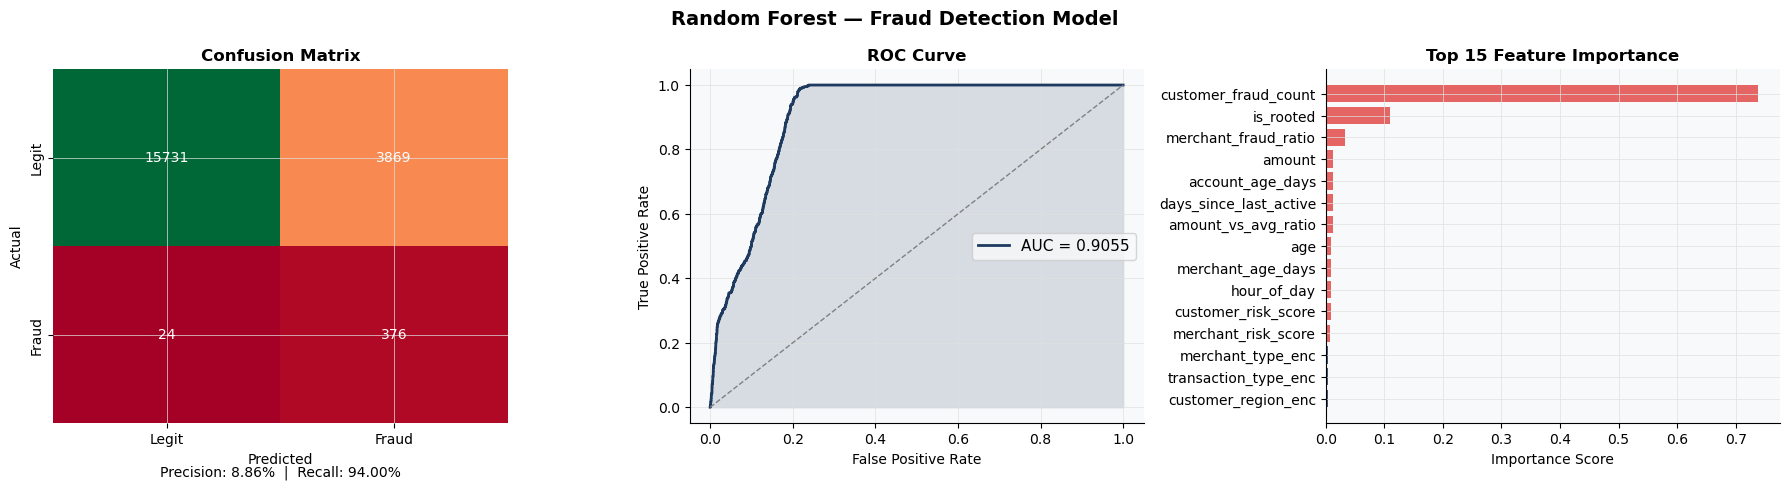

Saved: 07_model_performance.png


In [41]:
# Performance Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Fraud Detection Model',
             fontsize=14, fontweight='bold')

# 1. Confusion Matrix
cm_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_matrix, annot=True, fmt='d', ax=axes[0],
            cmap='RdYlGn', cbar=False,
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Metrics annotation
tn, fp, fn, tp = cm_matrix.ravel()
precision = tp/(tp+fp)
recall    = tp/(tp+fn)
axes[0].text(0.5, -0.15,
    f'Precision: {precision:.2%}  |  Recall: {recall:.2%}',
    transform=axes[0].transAxes, ha='center', fontsize=10)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_val     = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#1E3A5F', linewidth=2,
             label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#1E3A5F')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)

# 3. Feature Importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)
top15    = feat_imp.tail(15)
colors_f = ['#E24B4A' if v > feat_imp.median()
            else '#1E3A5F' for v in top15.values]
axes[2].barh(top15.index, top15.values,
             color=colors_f, alpha=0.85)
axes[2].set_title('Top 15 Feature Importance',
                   fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/07_model_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_model_performance.png")

Risk Score Distribution:
risk_tier
LOW         74570
HIGH        14852
CRITICAL     8010
MEDIUM       2568
Name: count, dtype: int64

Avg risk score (fraud txns): 75.7
Avg risk score (legit txns): 16.9


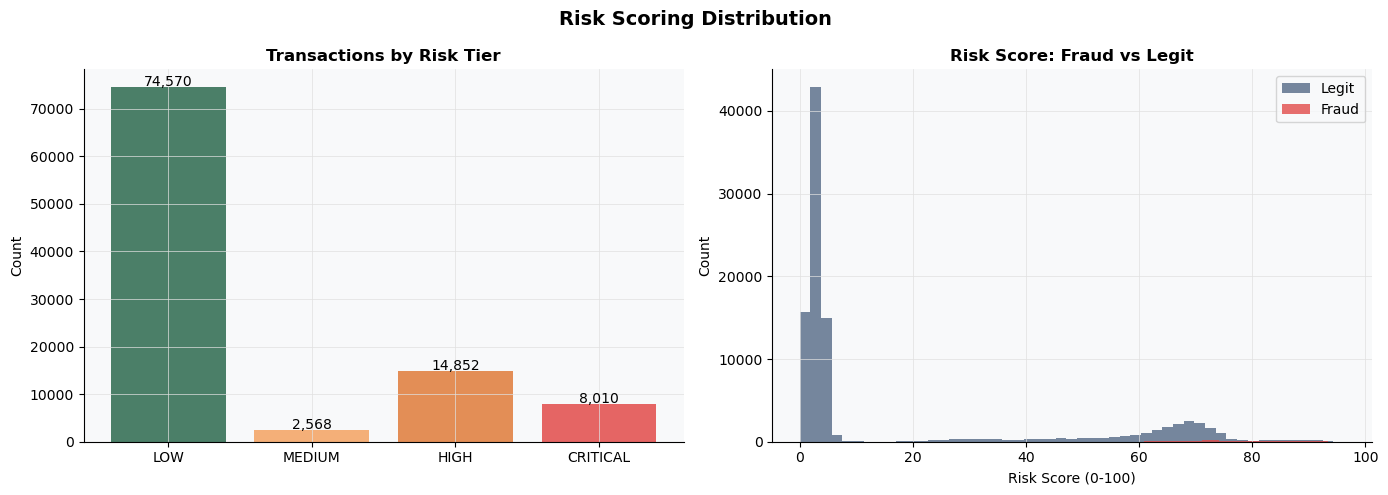

Saved: 08_risk_scoring.png


In [42]:
# Risk Scoring (0-100)
# Fraud probability → Risk Score 0-100
df_ml['fraud_probability'] = rf.predict_proba(X.fillna(0))[:,1]
df_ml['risk_score_model']  = (df_ml['fraud_probability'] * 100).round(1)

# Risk Tier
def risk_tier(score):
    if score >= 70:   return 'CRITICAL'
    elif score >= 40: return 'HIGH'
    elif score >= 20: return 'MEDIUM'
    else:             return 'LOW'

df_ml['risk_tier'] = df_ml['risk_score_model'].apply(risk_tier)

print("Risk Score Distribution:")
print(df_ml['risk_tier'].value_counts())
print(f"\nAvg risk score (fraud txns): "
      f"{df_ml[df_ml['fraud_flag']==True]['risk_score_model'].mean():.1f}")
print(f"Avg risk score (legit txns): "
      f"{df_ml[df_ml['fraud_flag']==False]['risk_score_model'].mean():.1f}")

# Risk tier chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Risk Scoring Distribution',
             fontsize=14, fontweight='bold')

# Tier distribution
tier_counts = df_ml['risk_tier'].value_counts()
tier_order  = ['LOW','MEDIUM','HIGH','CRITICAL']
tier_colors = ['#2D6A4F','#F4A261','#E07B39','#E24B4A']
vals = [tier_counts.get(t, 0) for t in tier_order]
bars = axes[0].bar(tier_order, vals,
                   color=tier_colors, alpha=0.85)
axes[0].set_title('Transactions by Risk Tier',
                   fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 val+200, f'{val:,}',
                 ha='center', fontsize=10)

# Risk score distribution — fraud vs legit
axes[1].hist(df_ml[df_ml['fraud_flag']==False]['risk_score_model'],
             bins=50, alpha=0.6, color='#1E3A5F', label='Legit')
axes[1].hist(df_ml[df_ml['fraud_flag']==True]['risk_score_model'],
             bins=50, alpha=0.8, color='#E24B4A', label='Fraud')
axes[1].set_title('Risk Score: Fraud vs Legit',
                   fontweight='bold')
axes[1].set_xlabel('Risk Score (0-100)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/08_risk_scoring.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_risk_scoring.png")

In [43]:
# Save Final Scored Dataset
import os

# Final scored output
output_cols = [
    'transaction_id','customer_id','amount','status',
    'fraud_flag','fraud_probability','risk_score_model',
    'risk_tier','is_rooted','blocked_account_flag',
    'channel_device_mismatch_flag','customer_risk_score',
    'customer_region','transaction_type','month','hour_of_day'
]

output_cols = [c for c in output_cols if c in df_ml.columns]
scored_df   = df_ml[output_cols].copy()

scored_df.to_csv("outputs/upi_scored_transactions.csv", index=False)

print(f"Scored dataset saved!")
print(f"Shape: {scored_df.shape}")
print(f"\nRisk tier summary:")
for tier in ['CRITICAL','HIGH','MEDIUM','LOW']:
    count = (scored_df['risk_tier']==tier).sum()
    fraud = scored_df[scored_df['risk_tier']==tier]['fraud_flag'].sum()
    print(f"  {tier:<10}: {count:>7,} txns | {fraud:>5} fraud")

Scored dataset saved!
Shape: (100000, 16)

Risk tier summary:
  CRITICAL  :   8,010 txns |  1443 fraud
  HIGH      :  14,852 txns |   550 fraud
  MEDIUM    :   2,568 txns |     7 fraud
  LOW       :  74,570 txns |     0 fraud
